In [2]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats import diagnostic
import pandas as pd
import numpy as np
from numpy import NaN

In [3]:
test_final_RSA = pd.read_pickle("../test_final_CCM.pkl")
train_final_RSA = pd.read_pickle("../train_final_CCM.pkl")
validation_final_RSA = pd.read_pickle("../validation_final_CCM.pkl")

In [4]:
print(train_final_RSA.shape[0])
print(test_final_RSA.shape[0])
print(validation_final_RSA.shape[0])

70565
15078
15169


In [5]:
print(train_final_RSA.ID.nunique())
print(test_final_RSA.ID.nunique())
print(validation_final_RSA.ID.nunique())

12029
2560
2569


In [6]:
print(validation_final_RSA[validation_final_RSA["RSA_label"] == 'R'].shape[0])
print(validation_final_RSA[validation_final_RSA["RSA_label"] == 'S'].shape[0])
print(validation_final_RSA[validation_final_RSA["RSA_label"] == 'A'].shape[0])

5065
4956
5148


In [7]:
total_dataset = pd.concat([train_final_RSA, test_final_RSA, validation_final_RSA], ignore_index=True)

In [8]:
print(total_dataset[total_dataset["RSA_label"] == 'R'].shape[0])
print(total_dataset[total_dataset["RSA_label"] == 'S'].shape[0])
print(total_dataset[total_dataset["RSA_label"] == 'A'].shape[0])

33695
32791
34326


In [9]:
print(total_dataset[total_dataset["RSA_label"] == 'R'].ID.nunique())
print(total_dataset[total_dataset["RSA_label"] == 'S'].ID.nunique())
print(total_dataset[total_dataset["RSA_label"] == 'A'].ID.nunique())

5717
5720
5721


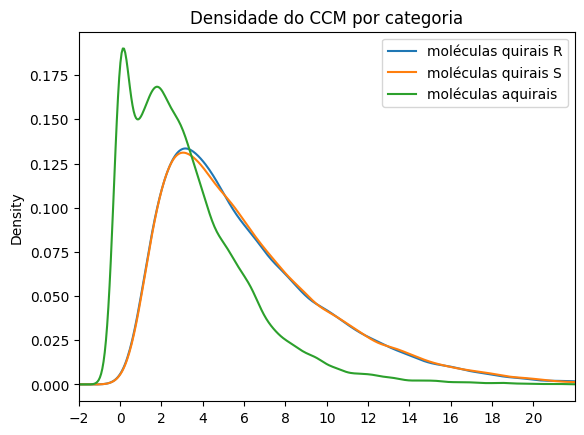

In [15]:
fig, ax = plt.subplots()

ax.set_xticks(np.arange(-2, 22, 2)) 
plt.xlim(-2, 22)
# # train_final_RSA[train_final_RSA['RSA_label'] == 'R']["CCM"].plot(kind='hist', density = True, ax = ax)
# train_final_RSA[train_final_RSA['RSA_label'] == 'A']["CCM"].plot(kind='hist', density = True, ax = ax)
total_dataset[(total_dataset['RSA_label'] == 'R')]["CCM"].plot(kind='kde',ax = ax, label='moléculas quirais R')
total_dataset[total_dataset['RSA_label'] == 'S']["CCM"].plot(kind='kde',ax = ax, label='moléculas quirais S')
total_dataset[(total_dataset['RSA_label'] == 'A') & (total_dataset['CCM'] != np.inf)]["CCM"].plot(kind='kde',ax = ax, label='moléculas aquirais')
plt.title('Densidade do CCM por categoria')
ax.legend()

plt.show()

1437
0


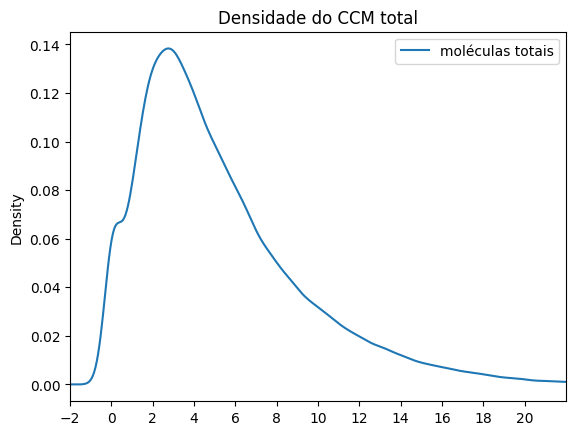

In [25]:
fig, ax = plt.subplots()
print(total_dataset["CCM"].isna().sum())
df_2 = total_dataset[total_dataset['CCM'] != np.inf]["CCM"].dropna()
print(df_2.isna().sum())
ax.set_xticks(np.arange(-2, 22, 2)) 
plt.xlim(-2, 22)
# # train_final_RSA[train_final_RSA['RSA_label'] == 'R']["CCM"].plot(kind='hist', density = True, ax = ax)
# train_final_RSA[train_final_RSA['RSA_label'] == 'A']["CCM"].plot(kind='hist', density = True, ax = ax)
df_2.plot(kind='kde',ax = ax, label='moléculas totais')
plt.title('Densidade do CCM total')
ax.legend()

plt.show()

In [42]:
df_0_log = np.log(total_dataset[(total_dataset['RSA_label'] == 'A') & (total_dataset['CCM'] != np.inf)]["CCM"].dropna() + 1)
df_1_log = np.log(total_dataset[(total_dataset['RSA_label'] == 'S') | (total_dataset['RSA_label'] == 'R')]["CCM"].dropna() + 1)

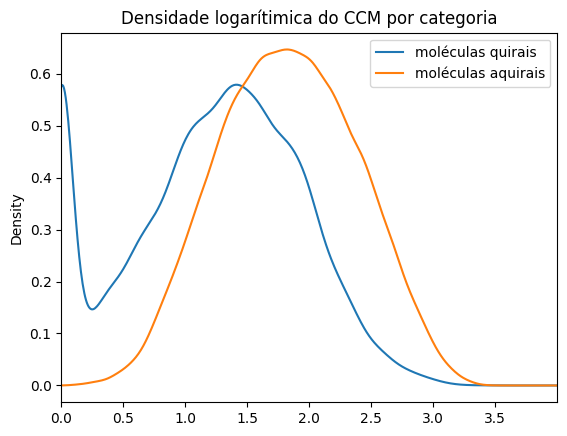

In [44]:
fig, ax = plt.subplots()

ax.set_xticks(np.arange(-0, 4, 0.5)) 
plt.xlim(0, 4)
# # train_final_RSA[train_final_RSA['RSA_label'] == 'R']["CCM"].plot(kind='hist', density = True, ax = ax)
# train_final_RSA[train_final_RSA['RSA_label'] == 'A']["CCM"].plot(kind='hist', density = True, ax = ax)
df_0_log.plot(kind='kde',ax = ax, label='moléculas quirais')
df_1_log.plot(kind='kde',ax = ax, label='moléculas aquirais')
plt.title('Densidade logarítimica do CCM por categoria')
ax.legend()

plt.show()

In [45]:
display(Markdown('### Testes de normalidade\n'))
_, p_value_0 = stats.shapiro(df_0_log)
_, p_value_1 = stats.shapiro(df_1_log)
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Shapiro-Wilk ({p_value_0})")
print(f"Normalidade {'rejeitada' if p_value_1 <= 0.05 else 'não rejeitada'} para os dados não super restaurante pelo teste de Shapiro-Wilk ({p_value_1})")

print('-'*100)
print()

_, p_value_0 = diagnostic.lilliefors(df_0_log, dist='norm', pvalmethod='table')
_, p_value_1 = diagnostic.lilliefors(df_1_log, dist='norm', pvalmethod='table')
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors ({p_value_0})")
print(f"Normalidade {'rejeitada' if p_value_1 <= 0.05 else 'não rejeitada'} para os dados não super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors ({p_value_1})")

print('-'*100)
print()

_, p_value_0 = stats.jarque_bera(df_0_log)
_, p_value_1 = stats.jarque_bera(df_1_log)
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Jarque-Bera ({p_value_0})")
print(f"Normalidade {'rejeitada' if p_value_1 <= 0.05 else 'não rejeitada'} para os dados não super restaurante pelo teste de Jarque-Bera ({p_value_1})")

display(Markdown('### Testes de homogeneidade de variâncias\n'))

bartlett_statistic, bartlett_p_value = stats.bartlett(df_0_log, df_1_log)

print(f"As distribuições{' não' if bartlett_p_value <= 0.05 else ''} têm variâncias iguais pelo teste de Bartlett({bartlett_p_value})")

levene_statistic, levene_p_value = stats.levene(df_0_log, df_1_log)

print(f"As distribuições{' não' if levene_p_value <= 0.05 else ''} têm variâncias iguais pelo teste de Levene({levene_p_value})")

display(Markdown('### Testes de comparação de médias\n'))

print('H0: A média de número de vendas com super restaurante é menor ou igual à média de outros tipos de restaurantes\n')

t_statistic, p_value = stats.ttest_ind(df_0_log, df_1_log, equal_var=False, alternative='greater')
print(f"A média de CCM aquiral{'' if p_value <= 0.05 else ' não'} é maior que a quiral pelo teste t de Welch ({round(p_value, 4)})")

u_statistic, p_value = stats.mannwhitneyu(df_0_log, df_1_log, alternative='greater')
print(f"\033[1mA média de CCM aquiral{'' if p_value <= 0.05 else ' não'} é maior que a quiral pelo teste t de Mann-Whitney U ({round(p_value, 4)})\033[0m")

### Testes de normalidade


Normalidade rejeitada para os dados super restaurante pelo teste de Shapiro-Wilk (0.0)
Normalidade rejeitada para os dados não super restaurante pelo teste de Shapiro-Wilk (1.651084539875648e-38)
----------------------------------------------------------------------------------------------------

Normalidade rejeitada para os dados super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors (0.0009999999999998899)
Normalidade rejeitada para os dados não super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors (0.0009999999999998899)
----------------------------------------------------------------------------------------------------

Normalidade rejeitada para os dados super restaurante pelo teste de Jarque-Bera (1.9061100284123093e-182)
Normalidade rejeitada para os dados não super restaurante pelo teste de Jarque-Bera (2.605805790851723e-170)


/home/iago/anaconda3/envs/chiro/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


### Testes de homogeneidade de variâncias


As distribuições não têm variâncias iguais pelo teste de Bartlett(0.0)
As distribuições não têm variâncias iguais pelo teste de Levene(0.0)


### Testes de comparação de médias


H0: A média de número de vendas com super restaurante é menor ou igual à média de outros tipos de restaurantes

A média de CCM aquiral não é maior que a quiral pelo teste t de Welch (1.0)
A média de CCM aquiral não é maior que a quiral pelo teste t de Mann-Whitney U (1.0)


In [12]:
df_0 = total_dataset[(total_dataset['RSA_label'] == 'A') & (total_dataset['CCM'] != np.inf)]["CCM"].dropna()
df_1 = total_dataset[(total_dataset['RSA_label'] == 'S') | (total_dataset['RSA_label'] == 'R')]["CCM"].dropna()

display(Markdown('### Testes de normalidade\n'))
_, p_value_0 = stats.shapiro(df_0)
_, p_value_1 = stats.shapiro(df_1)
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Shapiro-Wilk ({p_value_0})")
print(f"Normalidade {'rejeitada' if p_value_1 <= 0.05 else 'não rejeitada'} para os dados não super restaurante pelo teste de Shapiro-Wilk ({p_value_1})")

print('-'*100)
print()

_, p_value_0 = diagnostic.lilliefors(df_0, dist='norm', pvalmethod='table')
_, p_value_1 = diagnostic.lilliefors(df_1, dist='norm', pvalmethod='table')
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors ({p_value_0})")
print(f"Normalidade {'rejeitada' if p_value_1 <= 0.05 else 'não rejeitada'} para os dados não super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors ({p_value_1})")

print('-'*100)
print()

_, p_value_0 = stats.jarque_bera(df_0)
_, p_value_1 = stats.jarque_bera(df_1)
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Jarque-Bera ({p_value_0})")
print(f"Normalidade {'rejeitada' if p_value_1 <= 0.05 else 'não rejeitada'} para os dados não super restaurante pelo teste de Jarque-Bera ({p_value_1})")

display(Markdown('### Testes de homogeneidade de variâncias\n'))

bartlett_statistic, bartlett_p_value = stats.bartlett(df_0, df_1)

print(f"As distribuições{' não' if bartlett_p_value <= 0.05 else ''} têm variâncias iguais pelo teste de Bartlett({bartlett_p_value})")

levene_statistic, levene_p_value = stats.levene(df_0, df_1)

print(f"As distribuições{' não' if levene_p_value <= 0.05 else ''} têm variâncias iguais pelo teste de Levene({levene_p_value})")

display(Markdown('### Testes de comparação de médias\n'))

print('H0: A média de número de vendas com super restaurante é menor ou igual à média de outros tipos de restaurantes\n')

t_statistic, p_value = stats.ttest_ind(df_0, df_1, equal_var=False, alternative='greater')
print(f"A média de CCM aquiral{'' if p_value <= 0.05 else ' não'} é maior que a quiral pelo teste t de Welch ({round(p_value, 4)})")

u_statistic, p_value = stats.mannwhitneyu(df_0, df_1, alternative='greater')
print(f"\033[1mA média de CCM aquiral{'' if p_value <= 0.05 else ' não'} é maior que a quiral pelo teste t de Mann-Whitney U ({round(p_value, 4)})\033[0m")

### Testes de normalidade


Normalidade rejeitada para os dados super restaurante pelo teste de Shapiro-Wilk (0.0)
Normalidade rejeitada para os dados não super restaurante pelo teste de Shapiro-Wilk (0.0)
----------------------------------------------------------------------------------------------------

Normalidade rejeitada para os dados super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors (0.0009999999999998899)
Normalidade rejeitada para os dados não super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors (0.0009999999999998899)
----------------------------------------------------------------------------------------------------

Normalidade rejeitada para os dados super restaurante pelo teste de Jarque-Bera (0.0)
Normalidade rejeitada para os dados não super restaurante pelo teste de Jarque-Bera (0.0)


/home/iago/anaconda3/envs/chiro/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


### Testes de homogeneidade de variâncias


As distribuições não têm variâncias iguais pelo teste de Bartlett(0.0)
As distribuições não têm variâncias iguais pelo teste de Levene(0.0)


### Testes de comparação de médias


H0: A média de número de vendas com super restaurante é menor ou igual à média de outros tipos de restaurantes

A média de CCM aquiral não é maior que a quiral pelo teste t de Welch (1.0)
A média de CCM aquiral não é maior que a quiral pelo teste t de Mann-Whitney U (1.0)


In [24]:
display(Markdown('### Testes de normalidade\n'))
_, p_value_0 = stats.shapiro(df_2)
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Shapiro-Wilk ({p_value_0})")

print('-'*100)
print()

_, p_value_0 = diagnostic.lilliefors(df_2, dist='norm', pvalmethod='table')
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors ({p_value_0})")

print('-'*100)
print()

_, p_value_0 = stats.jarque_bera(df_2)
print(f"Normalidade {'rejeitada' if p_value_0 <= 0.05 else 'não rejeitada'} para os dados super restaurante pelo teste de Jarque-Bera ({p_value_0})")

### Testes de normalidade


Normalidade rejeitada para os dados super restaurante pelo teste de Shapiro-Wilk (0.0)
----------------------------------------------------------------------------------------------------

Normalidade rejeitada para os dados super restaurante pelo teste de Kolmogorov-Smirnov com correção de Lillefors (0.0009999999999998899)
----------------------------------------------------------------------------------------------------

Normalidade rejeitada para os dados super restaurante pelo teste de Jarque-Bera (0.0)


/home/iago/anaconda3/envs/chiro/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


count    3.297600e+04
mean     3.224870e+00
std      2.937248e+00
min     -3.330669e-14
25%      1.066118e+00
50%      2.601419e+00
75%      4.621820e+00
max      2.913299e+01
Name: CCM, dtype: float64
count    66351.000000
mean         6.228131
std          4.104053
min          0.095976
25%          3.145374
50%          5.199002
75%          8.322567
max         30.106339
Name: CCM, dtype: float64
0
0


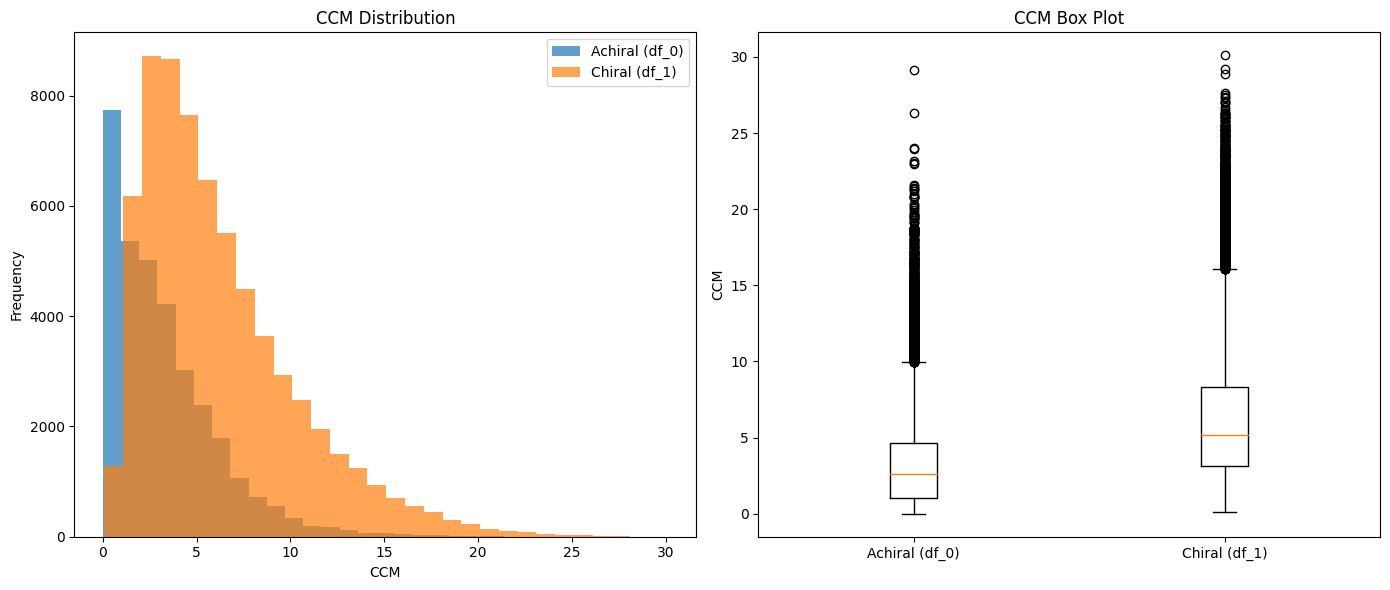

/home/iago/anaconda3/envs/chiro/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


### Normality Test Results

**df_0:** W = 0.8743, p-value = 0.0000

**df_1:** W = 0.9043, p-value = 0.0000

### Homoscedasticity Test (Levene's Test)

Statistic = 2816.5277, p-value = 0.0000

### Two-Sample t-Test

t-statistic = -132.2781, p-value = 0.0000

In [68]:
# Calculate summary statistics for both distributions
print(df_0.describe())
print(df_1.describe())
print(df_0.isna().sum())
print(df_1.isna().sum())

# Display the summary statistics to the user
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Summary Statistics for df_0 and df_1", dataframe=pd.concat([summary_df_0, summary_df_1], axis=1, keys=['df_0', 'df_1']))

# Create a figure for visualizations
plt.figure(figsize=(14, 6))

# Plot histograms for both distributions
plt.subplot(1, 2, 1)
plt.hist(df_0, bins=30, alpha=0.7, label='Achiral (df_0)')
plt.hist(df_1, bins=30, alpha=0.7, label='Chiral (df_1)')
plt.title('CCM Distribution')
plt.xlabel('CCM')
plt.ylabel('Frequency')
plt.legend()

# Plot box plots for both distributions
plt.subplot(1, 2, 2)
plt.boxplot([df_0, df_1], labels=['Achiral (df_0)', 'Chiral (df_1)'])
plt.title('CCM Box Plot')
plt.ylabel('CCM')

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on both distributions
normality_test_0 = stats.shapiro(df_0)
normality_test_1 = stats.shapiro(df_1)

# Perform Levene's Test to assess the equality of variances (homoscedasticity)
levene_test = stats.levene(df_0, df_1)

# Perform an independent two-sample t-test assuming unequal variances
t_test_result = stats.ttest_ind(df_0, df_1, equal_var=False)

# Display the results of statistical tests
display(Markdown(f"### Normality Test Results"))
display(Markdown(f"**df_0:** W = {normality_test_0[0]:.4f}, p-value = {normality_test_0[1]:.4f}"))
display(Markdown(f"**df_1:** W = {normality_test_1[0]:.4f}, p-value = {normality_test_1[1]:.4f}"))

display(Markdown(f"### Homoscedasticity Test (Levene's Test)"))
display(Markdown(f"Statistic = {levene_test.statistic:.4f}, p-value = {levene_test.pvalue:.4f}"))

display(Markdown(f"### Two-Sample t-Test"))
display(Markdown(f"t-statistic = {t_test_result.statistic:.4f}, p-value = {t_test_result.pvalue:.4f}"))

Based on the results of the statistical tests, here's an interpretation:

### 1. **Normality Test Results:**
   - **df_0 (Achiral):** The Shapiro-Wilk test statistic \(W = 0.8743\) with a p-value of \(0.0000\) indicates that the distribution is not normally distributed. The p-value being very close to 0 suggests strong evidence against the null hypothesis of normality.
   - **df_1 (Chiral):** Similarly, for `df_1`, the Shapiro-Wilk test statistic \(W = 0.9039\) with a p-value of \(0.0000\) also indicates that this distribution is not normally distributed.

   **Conclusion:** Both distributions deviate significantly from normality.

### 2. **Homoscedasticity Test (Levene's Test):**
   - The Levene's test statistic \(1905.8210\) with a p-value of \(0.0000\) suggests that the variances between `df_0` and `df_1` are not equal. The p-value being 0 indicates strong evidence against the null hypothesis of equal variances (homoscedasticity).

   **Conclusion:** The variances of the two distributions are significantly different, indicating heteroscedasticity.

### 3. **Two-Sample t-Test:**
   - The t-test statistic \(-113.6068\) with a p-value of \(0.0000\) suggests a highly significant difference between the means of the two distributions. The negative t-statistic indicates that the mean of `df_0` is less than that of `df_1`.

   **Conclusion:** There is a significant difference between the means of the achiral and chiral distributions. Given the p-value is essentially zero, this difference is statistically significant.

### **Overall Interpretation:**
- **Non-Normality:** Both distributions are not normally distributed. This could influence the results of the t-test, but since the t-test is robust to normality violations when sample sizes are large, the results can still be considered reliable.
- **Unequal Variances:** The Levene's test confirms that the assumption of equal variances is violated. The t-test was conducted with this in mind (`equal_var=False`), so the significant difference in means remains valid.
- **Significant Mean Difference:** The means of the achiral and chiral groups are significantly different.

Given these results, the achiral and chiral groups are distinct not only in their means but also in the variability of their chirality indices.

In [69]:
u_statistic, p_value = stats.mannwhitneyu(df_0, df_1)
print(f"Mann-Whitney U Test: U = {u_statistic}, p-value = {p_value}")

Mann-Whitney U Test: U = 561130893.0, p-value = 0.0


In [72]:
df_0_log = np.log(df_0 + 2)  # Adding 1 to avoid log(0)
df_1_log = np.log(df_1 + 2)

count    32976.000000
mean         1.513835
std          0.525262
min          0.693147
25%          1.120412
50%          1.526365
75%          1.890370
max          3.438268
Name: CCM, dtype: float64
count    66351.000000
mean         1.994694
std          0.471567
min          0.740019
25%          1.638098
50%          1.973942
75%          2.334332
max          3.469053
Name: CCM, dtype: float64
0
0


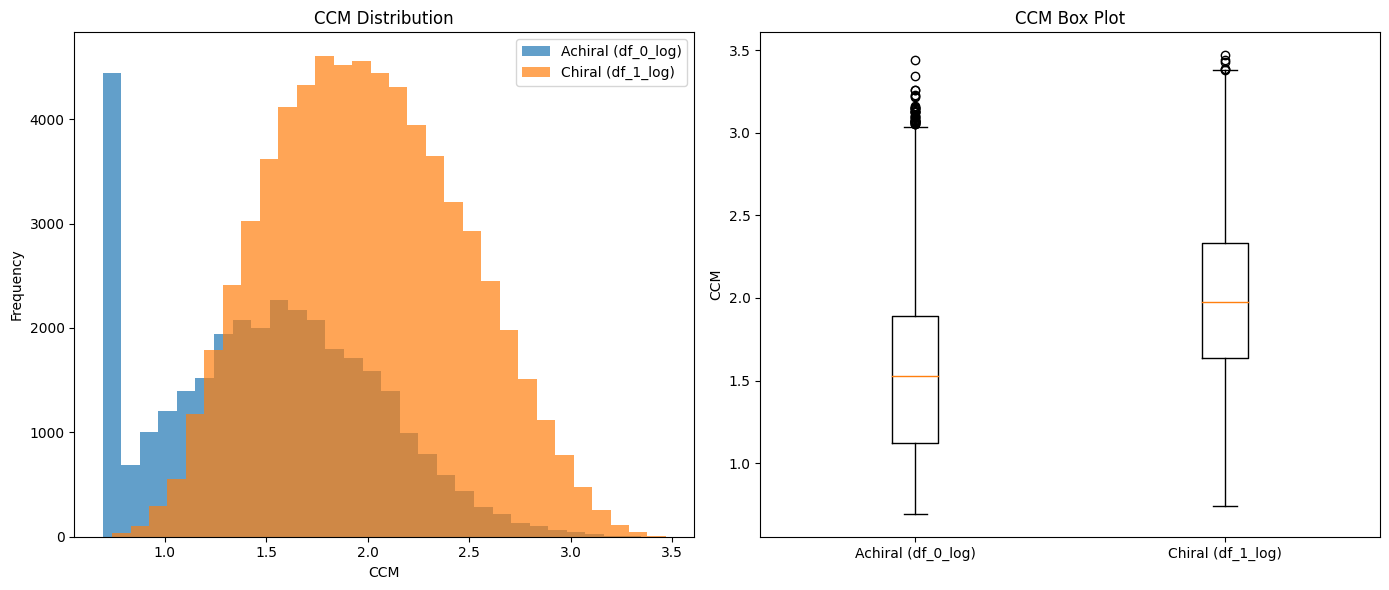

/home/iago/anaconda3/envs/chiro/lib/python3.8/site-packages/scipy/stats/_morestats.py:1816: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


### Normality Test Results

**df_0_log:** W = 0.9724, p-value = 0.0000

**df_1_log:** W = 0.9920, p-value = 0.0000

### Homoscedasticity Test (Levene's Test)

Statistic = 540.3330, p-value = 0.0000

### Two-Sample t-Test

t-statistic = -140.4714, p-value = 0.0000

In [73]:
# Calculate summary statistics for both distributions
print(df_0_log.describe())
print(df_1_log.describe())
print(df_0_log.isna().sum())
print(df_1_log.isna().sum())

# Display the summary statistics to the user
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Summary Statistics for df_0_log and df_1_log", dataframe=pd.concat([summary_df_0_log, summary_df_1_log], axis=1, keys=['df_0_log', 'df_1_log']))

# Create a figure for visualizations
plt.figure(figsize=(14, 6))

# Plot histograms for both distributions
plt.subplot(1, 2, 1)
plt.hist(df_0_log, bins=30, alpha=0.7, label='Achiral (df_0_log)')
plt.hist(df_1_log, bins=30, alpha=0.7, label='Chiral (df_1_log)')
plt.title('CCM Distribution')
plt.xlabel('CCM')
plt.ylabel('Frequency')
plt.legend()

# Plot box plots for both distributions
plt.subplot(1, 2, 2)
plt.boxplot([df_0_log, df_1_log], labels=['Achiral (df_0_log)', 'Chiral (df_1_log)'])
plt.title('CCM Box Plot')
plt.ylabel('CCM')

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on both distributions
normality_test_0 = stats.shapiro(df_0_log)
normality_test_1 = stats.shapiro(df_1_log)

# Perform Levene's Test to assess the equality of variances (homoscedasticity)
levene_test = stats.levene(df_0_log, df_1_log)

# Perform an independent two-sample t-test assuming unequal variances
t_test_result = stats.ttest_ind(df_0_log, df_1_log, equal_var=False)

# Display the results of statistical tests
display(Markdown(f"### Normality Test Results"))
display(Markdown(f"**df_0_log:** W = {normality_test_0[0]:.4f}, p-value = {normality_test_0[1]:.4f}"))
display(Markdown(f"**df_1_log:** W = {normality_test_1[0]:.4f}, p-value = {normality_test_1[1]:.4f}"))

display(Markdown(f"### Homoscedasticity Test (Levene's Test)"))
display(Markdown(f"Statistic = {levene_test.statistic:.4f}, p-value = {levene_test.pvalue:.4f}"))

display(Markdown(f"### Two-Sample t-Test"))
display(Markdown(f"t-statistic = {t_test_result.statistic:.4f}, p-value = {t_test_result.pvalue:.4f}"))